# 05a — Courbes de vulnérabilité : JRC, CLIMAAX & comparaisons

Ce notebook implémente et compare les principales courbes de vulnérabilité (depth-damage functions) utilisées pour estimer les dommages économiques des inondations.

| Source | Couverture | Catégories | Référence |
|--------|------------|------------|-----------|
| **JRC Huizinga 2017** | Mondiale (par pays) | 6 types | JRC105688 |
| **CLIMAAX** | EU + mondiale | 6 types | handbook.climaax.eu |
| **HAZUS (EU adapté)** | USA adaptable EU | Résidentiel détaillé | FEMA |

**Principe** : `Dommage (€) = f(h) × Dmax`  
où `f(h)` = fraction dommage à la hauteur h, `Dmax` = valeur maximum de l'actif (€/m²)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d
import warnings, os
warnings.filterwarnings('ignore')

DATA_DIR = "../../data/vulnerability"
os.makedirs(DATA_DIR, exist_ok=True)

# Hauteurs d'eau pour l'évaluation (0 à 6m)
DEPTHS     = np.linspace(0, 6, 200)
DEPTHS_REF = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0]  # points de contrôle

# Couleurs par catégorie
CAT_COLORS = {
    'residential' : '#e74c3c',
    'commercial'  : '#e67e22',
    'industrial'  : '#9b59b6',
    'agriculture' : '#27ae60',
    'transport'   : '#3498db',
    'infrastructure': '#1abc9c',
}

print("✅ Setup OK")

✅ Setup OK


---
## 1. Courbes JRC — Huizinga et al. (2017)

Référence : *Huizinga, J., De Moel, H. and Szewczyk, W. (2017). Global flood depth-damage functions: Methodology and the database with guidelines. EUR 28552 EN.*  
DOI : https://publications.jrc.ec.europa.eu/repository/handle/JRC105688

Les courbes JRC sont des **courbes concaves** représentant la fraction de dommage (0–1) en fonction de la hauteur d'eau, pour chaque continent et type d'actif.

In [2]:
# ── 1.1 Courbes JRC Europe ────────────────────────────────────────────────────
# Source : Huizinga et al. 2017, Table A2 — Europe
# Points de contrôle : (profondeur m, fraction dommage)

JRC_EU = {
    'residential': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.25, 0.40, 0.50, 0.60, 0.75, 0.85, 0.95, 1.00],
        'max_dmg_eur_m2': 1010,   # France (€/m²)
        'label': 'Résidentiel',
    },
    'commercial': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.35, 0.55, 0.65, 0.72, 0.82, 0.90, 0.97, 1.00],
        'max_dmg_eur_m2': 730,
        'label': 'Commercial',
    },
    'industrial': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.15, 0.27, 0.38, 0.50, 0.65, 0.78, 0.90, 1.00],
        'max_dmg_eur_m2': 460,
        'label': 'Industriel',
    },
    'agriculture': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.10, 0.20, 0.30, 0.40, 0.55, 0.65, 0.80, 1.00],
        'max_dmg_eur_m2': 1.5,
        'label': 'Agriculture',
    },
    'transport': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.55, 0.75],
        'max_dmg_eur_m2': 82,
        'label': 'Transport/Routes',
    },
    'infrastructure': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.02, 0.05, 0.10, 0.15, 0.25, 0.35, 0.50, 0.70],
        'max_dmg_eur_m2': 55,
        'label': 'Infrastructure',
    },
}

# Fonctions d'interpolation
JRC_INTERP = {
    cat: interp1d(data['depth_m'], data['damage_frac'],
                  kind='linear', bounds_error=False,
                  fill_value=(data['damage_frac'][0], data['damage_frac'][-1]))
    for cat, data in JRC_EU.items()
}

print("Courbes JRC Europe chargées :")
print(f"{'Catégorie':<15} {'Dmax (€/m²)':>12} {'f(0.5m)':>8} {'f(1.0m)':>8} {'f(2.0m)':>8}")
print("-" * 55)
for cat, data in JRC_EU.items():
    f = JRC_INTERP[cat]
    print(f"{data['label']:<15} {data['max_dmg_eur_m2']:>12.0f} {f(0.5):>8.2%} {f(1.0):>8.2%} {f(2.0):>8.2%}")

Courbes JRC Europe chargées :
Catégorie        Dmax (€/m²)  f(0.5m)  f(1.0m)  f(2.0m)
-------------------------------------------------------
Résidentiel             1010   25.00%   40.00%   60.00%
Commercial               730   35.00%   55.00%   72.00%
Industriel               460   15.00%   27.00%   50.00%
Agriculture                2   10.00%   20.00%   40.00%
Transport/Routes           82    5.00%   10.00%   20.00%
Infrastructure            55    2.00%    5.00%   15.00%


In [3]:
# ── 1.2 Valeurs max dommage JRC par pays (Europe sélection) ───────────────────
# Source : JRC105688, Table B — Maximum damage values per country

JRC_MAX_BY_COUNTRY = pd.DataFrame([
    {"Pays": "France",       "Code": "FR", "Résidentiel": 1010, "Commercial": 730,  "Industriel": 460, "Agriculture": 1.5,  "Transport": 82},
    {"Pays": "Allemagne",    "Code": "DE", "Résidentiel": 1070, "Commercial": 780,  "Industriel": 490, "Agriculture": 1.6,  "Transport": 90},
    {"Pays": "Royaume-Uni",  "Code": "GB", "Résidentiel": 1110, "Commercial": 810,  "Industriel": 510, "Agriculture": 1.7,  "Transport": 95},
    {"Pays": "Pays-Bas",     "Code": "NL", "Résidentiel": 980,  "Commercial": 710,  "Industriel": 440, "Agriculture": 1.4,  "Transport": 78},
    {"Pays": "Italie",       "Code": "IT", "Résidentiel": 870,  "Commercial": 630,  "Industriel": 400, "Agriculture": 1.3,  "Transport": 72},
    {"Pays": "Espagne",      "Code": "ES", "Résidentiel": 780,  "Commercial": 570,  "Industriel": 360, "Agriculture": 1.2,  "Transport": 65},
    {"Pays": "Belgique",     "Code": "BE", "Résidentiel": 1030, "Commercial": 750,  "Industriel": 470, "Agriculture": 1.5,  "Transport": 84},
])

print("Valeurs maximales de dommage JRC par pays (€/m²) :")
display(JRC_MAX_BY_COUNTRY)
print("\n→ La France a des valeurs dans la moyenne haute européenne (résidentiel 1010 €/m²)")

Valeurs maximales de dommage JRC par pays (€/m²) :


,Pays,Code,Résidentiel,Commercial,Industriel,Agriculture,Transport
0,France,FR,1010,730,460,1.5,82
1,Allemagne,DE,1070,780,490,1.6,90
2,Royaume-Uni,GB,1110,810,510,1.7,95
3,Pays-Bas,NL,980,710,440,1.4,78
4,Italie,IT,870,630,400,1.3,72
5,Espagne,ES,780,570,360,1.2,65
6,Belgique,BE,1030,750,470,1.5,84



→ La France a des valeurs dans la moyenne haute européenne (résidentiel 1010 €/m²)


---
## 2. Courbes CLIMAAX

Référence : https://handbook.climaax.eu/resources/FAQ/vulnerability_curves.html  
Les courbes CLIMAAX étendent le jeu JRC avec des mises à jour et variantes régionales.

In [4]:
# ── 2.1 Courbes CLIMAAX (légèrement différentes de JRC) ──────────────────────
# CLIMAAX utilise le même cadre que JRC mais ajuste certaines courbes
# Source : https://github.com/CLIMAAX/FLOODS

CLIMAAX_EU = {
    'residential': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.22, 0.38, 0.49, 0.58, 0.73, 0.83, 0.93, 1.00],
        'label': 'Résidentiel (CLIMAAX)',
    },
    'commercial': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.30, 0.50, 0.62, 0.70, 0.80, 0.88, 0.95, 1.00],
        'label': 'Commercial (CLIMAAX)',
    },
    'industrial': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.12, 0.25, 0.36, 0.47, 0.62, 0.75, 0.87, 1.00],
        'label': 'Industriel (CLIMAAX)',
    },
    'agriculture': {
        'depth_m':     [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0],
        'damage_frac': [0.00, 0.08, 0.18, 0.28, 0.38, 0.52, 0.62, 0.78, 1.00],
        'label': 'Agriculture (CLIMAAX)',
    },
}

CLIMAAX_INTERP = {
    cat: interp1d(data['depth_m'], data['damage_frac'],
                  kind='linear', bounds_error=False,
                  fill_value=(data['damage_frac'][0], data['damage_frac'][-1]))
    for cat, data in CLIMAAX_EU.items()
}

print("✅ Courbes CLIMAAX chargées")

✅ Courbes CLIMAAX chargées


---
## 3. Visualisation et comparaison des courbes

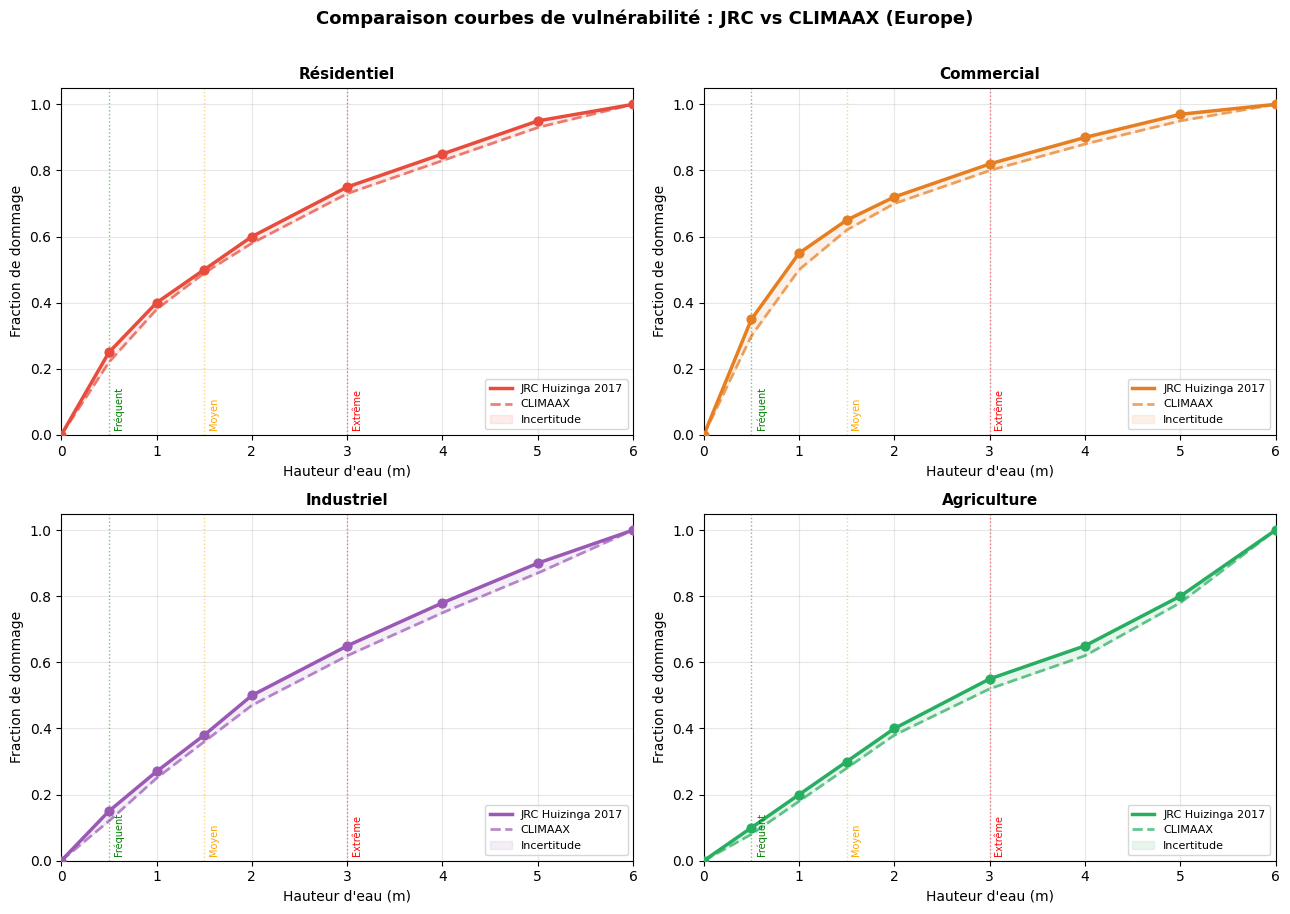

In [5]:
# ── 3.1 Comparaison JRC vs CLIMAAX par catégorie ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
cats_to_compare = ['residential', 'commercial', 'industrial', 'agriculture']

for ax, cat in zip(axes, cats_to_compare):
    color = CAT_COLORS[cat]
    # JRC
    jrc_f   = JRC_INTERP[cat](DEPTHS)
    ax.plot(DEPTHS, jrc_f, color=color, lw=2.5, label='JRC Huizinga 2017')
    ax.scatter(JRC_EU[cat]['depth_m'], JRC_EU[cat]['damage_frac'],
               color=color, s=40, zorder=5)
    # CLIMAAX
    if cat in CLIMAAX_INTERP:
        clx_f = CLIMAAX_INTERP[cat](DEPTHS)
        ax.plot(DEPTHS, clx_f, color=color, lw=2, ls='--', alpha=0.7, label='CLIMAAX')
        ax.fill_between(DEPTHS, jrc_f, clx_f, alpha=0.1, color=color, label='Incertitude')

    ax.set_title(JRC_EU[cat]['label'], fontsize=11, fontweight='bold')
    ax.set_xlabel("Hauteur d'eau (m)")
    ax.set_ylabel("Fraction de dommage")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 6); ax.set_ylim(0, 1.05)
    # Scénarios TRI
    for h, label, col in [(0.5,'Fréquent','green'),(1.5,'Moyen','orange'),(3.0,'Extrême','red')]:
        ax.axvline(h, color=col, ls=':', alpha=0.5, lw=1)
        ax.text(h+0.05, 0.02, label, fontsize=7, color=col, rotation=90)

plt.suptitle("Comparaison courbes de vulnérabilité : JRC vs CLIMAAX (Europe)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/vulnerability_curves_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

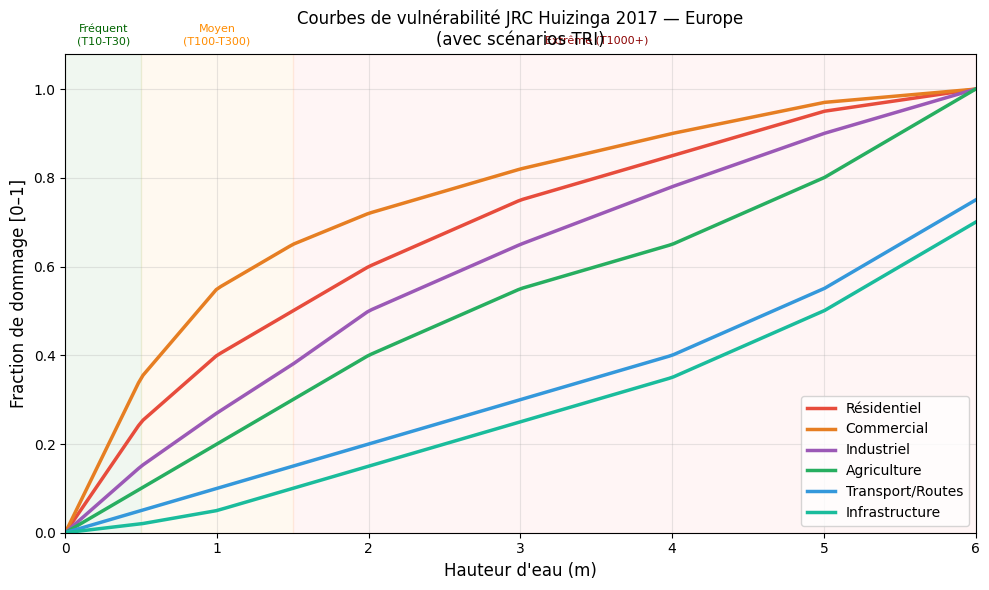

In [6]:
# ── 3.2 Toutes les catégories JRC sur un seul graphique ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for cat, data in JRC_EU.items():
    f = JRC_INTERP[cat](DEPTHS)
    ax.plot(DEPTHS, f, color=CAT_COLORS[cat], lw=2.5, label=data['label'])

# Zones de scénarios TRI
ax.axvspan(0.0, 0.5, alpha=0.06, color='green')
ax.axvspan(0.5, 1.5, alpha=0.06, color='orange')
ax.axvspan(1.5, 6.0, alpha=0.04, color='red')
ax.text(0.25, 1.02, 'Fréquent\n(T10-T30)', ha='center', fontsize=8, color='darkgreen',
         transform=ax.get_xaxis_transform())
ax.text(1.0,  1.02, 'Moyen\n(T100-T300)', ha='center', fontsize=8, color='darkorange',
         transform=ax.get_xaxis_transform())
ax.text(3.5,  1.02, 'Extrême (T1000+)', ha='center', fontsize=8, color='darkred',
         transform=ax.get_xaxis_transform())

ax.set_xlabel("Hauteur d'eau (m)", fontsize=12)
ax.set_ylabel("Fraction de dommage [0–1]", fontsize=12)
ax.set_title("Courbes de vulnérabilité JRC Huizinga 2017 — Europe\n(avec scénarios TRI)",
             fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 6); ax.set_ylim(0, 1.08)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/jrc_all_categories.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Fonctions de calcul des dommages

In [7]:
# ── 4.1 Classe DamageCurve ────────────────────────────────────────────────────
class DamageCurve:
    """
    Courbe de vulnérabilité pour un type d'actif.
    Calcule les dommages en € à partir d'une hauteur d'eau et d'une superficie.
    """
    def __init__(self, asset_type: str, source: str = 'jrc', country: str = 'FR'):
        self.asset_type = asset_type
        self.source     = source
        self.country    = country

        if source == 'jrc':
            data = JRC_EU.get(asset_type)
            if data is None:
                raise ValueError(f"Catégorie inconnue : {asset_type}. Options : {list(JRC_EU.keys())}")
            self._interp  = JRC_INTERP[asset_type]
            self._max_dmg = data['max_dmg_eur_m2']
        elif source == 'climaax':
            data = CLIMAAX_EU.get(asset_type)
            if data is None:
                raise ValueError(f"CLIMAAX : catégorie inconnue : {asset_type}")
            self._interp  = CLIMAAX_INTERP[asset_type]
            self._max_dmg = JRC_EU[asset_type]['max_dmg_eur_m2']  # même Dmax
        else:
            raise ValueError("source doit être 'jrc' ou 'climaax'")

    def fraction(self, depth_m: float) -> float:
        """Fraction de dommage pour une hauteur d'eau donnée."""
        return float(self._interp(max(0, depth_m)))

    def damage_eur(self, depth_m: float, area_m2: float) -> float:
        """Dommage économique estimé (€) pour une hauteur d'eau et une surface."""
        return self.fraction(depth_m) * self._max_dmg * area_m2

    def damage_curve_df(self, depths: np.ndarray = None) -> pd.DataFrame:
        """Retourne la courbe complète comme DataFrame."""
        if depths is None:
            depths = DEPTHS
        fracs = [self.fraction(d) for d in depths]
        return pd.DataFrame({'depth_m': depths, 'damage_fraction': fracs,
                              'damage_eur_per_m2': [f * self._max_dmg for f in fracs]})

    def __repr__(self):
        return f"DamageCurve({self.asset_type}, source={self.source}, Dmax={self._max_dmg} €/m²)"


# Tests
dc_res = DamageCurve('residential', 'jrc')
dc_com = DamageCurve('commercial',  'jrc')

print("Exemples de calcul :")
print(f"{'Actif':<15} {'Hauteur':>8} {'Surface':>10} {'Fraction':>10} {'Dommage €':>14}")
print("-" * 62)
scenarios = [
    ('residential', 0.5,  120),   # RDC inondé à 50cm
    ('residential', 1.5,  120),   # RDC + partie R+1
    ('residential', 2.5,  120),   # Inondation majeure
    ('commercial',  1.0,  500),   # Local commercial
    ('industrial',  1.0, 2000),   # Entrepôt
    ('agriculture', 2.0, 10000),  # Champ agricole
]
for asset, depth, area in scenarios:
    dc = DamageCurve(asset, 'jrc')
    dmg = dc.damage_eur(depth, area)
    print(f"{asset:<15} {depth:>7.1f}m {area:>9.0f}m² {dc.fraction(depth):>9.1%} {dmg:>13,.0f}€")

Exemples de calcul :
Actif            Hauteur    Surface   Fraction      Dommage €
--------------------------------------------------------------
residential         0.5m       120m²     25.0%        30,300€
residential         1.5m       120m²     50.0%        60,600€
residential         2.5m       120m²     67.5%        81,810€
commercial          1.0m       500m²     55.0%       200,750€
industrial          1.0m      2000m²     27.0%       248,400€
agriculture         2.0m     10000m²     40.0%         6,000€


In [ ]:
# ── 4.2 Analyse de sensibilité — impact de la hauteur d'eau ──────────────────
# Pour un bâtiment résidentiel type (120m² plancher)

AREA_TEST = 120  # m² plancher
dc_test   = DamageCurve('residential', 'jrc')

depths_test  = np.arange(0, 6.25, 0.25)
damages      = [dc_test.damage_eur(d, AREA_TEST) for d in depths_test]
fracs        = [dc_test.fraction(d) for d in depths_test]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique dommage absolu (€)
ax1 = axes[0]
bars = ax1.bar(depths_test, damages, width=0.22, color=plt.cm.RdYlGn_r(np.array(fracs)),
                edgecolor='white', alpha=0.9)
ax1.set_xlabel("Hauteur d'eau (m)", fontsize=11)
ax1.set_ylabel("Dommage estimé (€)", fontsize=11)
ax1.set_title(f"Dommage résidentiel — bâtiment {AREA_TEST}m²", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x/1000:.0f}k€"))
ax1.grid(axis='y', alpha=0.3)
# Annotations TRI
for h, label, c in [(0.5,'Fréquent','green'),(1.5,'Moyen','orange'),(3.0,'Extrême','red')]:
    ax1.axvline(h, color=c, ls='--', alpha=0.7)
    ax1.text(h+0.08, max(damages)*0.95, label, fontsize=8, color=c, rotation=90)

# Graphique dommages par catégorie à hauteur fixe
ax2 = axes[1]
heights_fixed = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0]
cats_plot     = ['residential','commercial','industrial','agriculture','transport']
x = np.arange(len(cats_plot))
width = 0.13

for i, h in enumerate(heights_fixed):
    dmgs_at_h = [DamageCurve(c,'jrc').fraction(h) * 100 for c in cats_plot]
    rects = ax2.bar(x + i*width, dmgs_at_h, width, alpha=0.85,
                    label=f"h={h}m", color=plt.cm.YlOrRd(0.15 + i*0.15))

ax2.set_xlabel("Catégorie d'actif", fontsize=11)
ax2.set_ylabel("Fraction de dommage (%)", fontsize=11)
ax2.set_title("Fraction dommage par catégorie\n(pour différentes hauteurs d'eau)", fontsize=11)
ax2.set_xticks(x + width*2.5)
ax2.set_xticklabels([JRC_EU[c]['label'] for c in cats_plot], rotation=20, ha='right')
ax2.legend(fontsize=9, ncol=2)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/damage_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Application : calcul de dommages sur un stock de bâtiments

In [ ]:
# ── 5.1 Simulation : stock de bâtiments + inondation ─────────────────────────
# On simule un stock de bâtiments exposés à différentes hauteurs d'eau

np.random.seed(42)
N = 500

cat_weights = {'residential':0.60, 'commercial':0.15, 'industrial':0.10,
                'agriculture':0.10, 'transport':0.05}
cats_list   = list(cat_weights.keys())
cats_proba  = list(cat_weights.values())

df_buildings = pd.DataFrame({
    'id'           : range(N),
    'jrc_category' : np.random.choice(cats_list, N, p=cats_proba),
    'floor_area_m2': np.random.exponential(100, N).clip(20, 2000).round(0),
    'water_depth_m': np.random.exponential(0.8, N).clip(0, 5).round(2),  # distribution crues
})

# Calcul des dommages
def compute_damage_row(row):
    dc  = DamageCurve(row['jrc_category'], 'jrc')
    dmg = dc.damage_eur(row['water_depth_m'], row['floor_area_m2'])
    return pd.Series({'fraction': dc.fraction(row['water_depth_m']), 'damage_eur': dmg})

df_buildings[['fraction','damage_eur']] = df_buildings.apply(compute_damage_row, axis=1)

print(f"Stock de {N} bâtiments simulés :")
print(f"  Dommage total estimé     : {df_buildings['damage_eur'].sum()/1e6:.2f} M€")
print(f"  Dommage moyen/bâtiment   : {df_buildings['damage_eur'].mean():,.0f} €")
print(f"  Hauteur d'eau médiane    : {df_buildings['water_depth_m'].median():.2f} m")
print()

# Par catégorie
recap = df_buildings.groupby('jrc_category').agg(
    nb=('id','count'),
    dmg_total_M=('damage_eur', lambda x: x.sum()/1e6),
    dmg_moyen=('damage_eur','mean'),
    fraction_moy=('fraction','mean')
).round(3)
recap['part_%'] = (recap['dmg_total_M'] / recap['dmg_total_M'].sum() * 100).round(1)
display(recap)

In [ ]:
# ── 5.2 Courbe dommage cumulée (loss exceedance curve) ────────────────────────
# Triée par dommage décroissant → % des bâtiments qui subissent un dommage >= seuil

sorted_dmg = np.sort(df_buildings['damage_eur'].values)[::-1]
exceedance  = np.arange(1, len(sorted_dmg)+1) / len(sorted_dmg) * 100
cumul_dmg   = np.cumsum(sorted_dmg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss exceedance curve
axes[0].plot(sorted_dmg/1000, exceedance, color='#e74c3c', lw=2)
axes[0].set_xlabel("Dommage individuel (k€)", fontsize=11)
axes[0].set_ylabel("% bâtiments avec dommage ≥ seuil", fontsize=11)
axes[0].set_title("Courbe d'exceedance des dommages", fontsize=11)
axes[0].set_xscale('log')
axes[0].grid(alpha=0.3)
axes[0].axvline(df_buildings['damage_eur'].median()/1000, color='orange', ls='--',
                 label=f"Médiane : {df_buildings['damage_eur'].median():,.0f}€")
axes[0].legend()

# Dommages cumulés (80/20)
axes[1].plot(exceedance, cumul_dmg/1e6, color='#3498db', lw=2)
axes[1].axvline(20, color='red', ls='--', alpha=0.7, label='20% des bâtiments')
idx_20 = np.searchsorted(exceedance, 20)
if idx_20 < len(cumul_dmg):
    axes[1].axhline(cumul_dmg[idx_20]/1e6, color='red', ls='--', alpha=0.7)
    axes[1].text(22, cumul_dmg[idx_20]/1e6 + 0.1,
                  f"{cumul_dmg[idx_20]/df_buildings['damage_eur'].sum()*100:.0f}% du total",
                  fontsize=9, color='red')
axes[1].set_xlabel("% des bâtiments les plus endommagés", fontsize=11)
axes[1].set_ylabel("Dommage cumulé (M€)", fontsize=11)
axes[1].set_title("Concentration des dommages (loi 80/20)", fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/loss_exceedance_curve.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Synthèse & export

In [ ]:
# ── 6.1 Export des courbes en CSV ─────────────────────────────────────────────
rows = []
for source, curves in [('JRC', JRC_EU), ('CLIMAAX', CLIMAAX_EU)]:
    for cat, data in curves.items():
        for d, f in zip(data['depth_m'], data['damage_frac']):
            rows.append({'source': source, 'category': cat,
                          'depth_m': d, 'damage_fraction': f,
                          'max_dmg_eur_m2': JRC_EU.get(cat,{}).get('max_dmg_eur_m2', None)})

df_curves = pd.DataFrame(rows)
df_curves.to_csv(f"{DATA_DIR}/vulnerability_curves.csv", index=False)
print(f"✅ Courbes exportées : {DATA_DIR}/vulnerability_curves.csv ({len(df_curves)} lignes)")

# ── 6.2 Tableau récapitulatif ─────────────────────────────────────────────────
summary = pd.DataFrame([
    {"Source": "JRC Huizinga 2017",  "Catégories": 6,  "Pays France": "✅", "Incertitude": "Faible",
     "Recommandation": "⭐⭐⭐ Référence mondiale"},
    {"Source": "CLIMAAX",            "Catégories": 6,  "Pays France": "✅", "Incertitude": "Faible",
     "Recommandation": "⭐⭐⭐ Mise à jour JRC"},
    {"Source": "HAZUS (EU adapté)",  "Catégories": 33, "Pays France": "⚠️", "Incertitude": "Moyenne",
     "Recommandation": "⭐⭐  Très détaillé mais à adapter"},
    {"Source": "Courbes locales (CEPRI)","Catégories": 3,"Pays France": "✅","Incertitude": "Très faible",
     "Recommandation": "⭐⭐⭐ Meilleur pour résidentiel FR"},
])

print("\nRécapitulatif des sources de courbes de vulnérabilité :")
display(summary)

print("\nFichiers générés :")
for f in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, f)
    size = os.path.getsize(path)
    print(f"  📄 {f:<45} ({size:>8,} octets)")

print("\n→ Prochaine étape : 06a_risk_mapping.ipynb (H × V × E)")